# Sections 9.5, 9.6 and 10: GRU, Bidirectional GRU, BERT Base

**Owner:** Zawad | **Notebook:** `05_gru_bert_zawad.ipynb` | **Runtime:** Colab T4

This notebook covers the three models the brief requires that Hasib and Fabiha did
not train. It reads the frozen Phase 0 artifacts from `01_phase1_mahir.ipynb`. It
never writes to them.

| Section | Model | Configs | Representation |
| --- | --- | --- | --- |
| 9.5 | GRU | S1, S2, S3 | GloVe 50d / Word2Vec 50d |
| 9.6 | Bidirectional GRU | S1, S2, S3 | GloVe 50d / Word2Vec 50d |
| 10 | BERT Base | B1, B2, B3 | WordPiece (pretrained) |

Nine required runs plus one sequence-length ablation.

Two things are inherited, not chosen here. The `S1`, `S2`, `S3` grid is copied from
Hasib's notebook so all six recurrent models differ only by cell type. All scoring
comes from `utils.evaluation`, the shared module, so no model is measured by code
only one person has read.

The epoch cap is 30. The group agreed this after finding the two earlier notebooks
disagreed.

## Section 0: Environment

GPU memory growth is set before any TensorFlow operation. This notebook uses
TensorFlow for sections 9.5 and 9.6 and PyTorch for section 10. TensorFlow claims the
whole device on first use by default. Without growth enabled, the `Trainer` in
section 10 finds no free memory and fails. This cell must stay first.

In [ ]:
import os, sys, gc, json, time, random, platform
import numpy as np

import tensorflow as tf
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"python      : {sys.version.split()[0]}")
print(f"platform    : {platform.system()} {platform.release()}")
print(f"tensorflow  : {tf.__version__}")
print(f"keras       : {tf.keras.__version__}")
print(f"TF GPUs     : {[g.name for g in tf.config.list_physical_devices('GPU')]}")
print(f"seed        : {SEED}, memory growth enabled")

python      : 3.13.15
platform    : Linux 6.6.122+
tensorflow  : 2.20.0
keras       : 3.13.2
TF GPUs     : ['/physical_device:GPU:0']
seed        : 42, memory growth enabled


## Section 0b: Frozen artifacts and the checksum gate

Everything below is read-only. The splits, embedding matrices and padded sequence
arrays were built once by `01_phase1_mahir.ipynb`. They must not be regenerated.
Hasib's and Fabiha's completed runs are measurements against these exact files.

The gate is two checksums. `pd.util.hash_pandas_object` over the cleaned text column
changes if one character of preprocessing changed, if the split boundary moved, or if
row order shifted. Hasib and Fabiha assert the same two numbers.

If this cell raises, nothing below is comparable to their results. Stop and post the
mismatch to the group.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/cse440_project")
if not DATA_DIR.exists():
    DATA_DIR = Path("cse440_project")

SPLIT_DIR   = DATA_DIR / "splits"
REPR_DIR    = DATA_DIR / "representations"
RESULTS_DIR = DATA_DIR / "results" / "zawad"
FIG_DIR     = DATA_DIR / "figures" / "zawad"

assert SPLIT_DIR.exists(), (
    f"{SPLIT_DIR} not found. If cse440_project is under 'Shared with me', "
    "right-click it in Drive and choose Organise > Add shortcut to Drive."
)

sys.path.insert(0, str(DATA_DIR))
import utils.evaluation as ev

train_df = pd.read_parquet(SPLIT_DIR / "train.parquet")
val_df   = pd.read_parquet(SPLIT_DIR / "val.parquet")
test_df  = pd.read_parquet(SPLIT_DIR / "test.parquet")

CHECKSUM_TRAIN = 13885266476465583340
CHECKSUM_TEST  = 259686901888230227

chk_train = int(pd.util.hash_pandas_object(train_df.text_clean).sum())
chk_test  = int(pd.util.hash_pandas_object(test_df.text_clean).sum())

print(f"shapes      : train {train_df.shape}  val {val_df.shape}  test {test_df.shape}")
print(f"columns     : {list(train_df.columns)}")
print(f"checksum tr : {chk_train}")
print(f"checksum te : {chk_test}")

assert chk_train == CHECKSUM_TRAIN, "TRAIN CHECKSUM MISMATCH — stop and post to the group"
assert chk_test  == CHECKSUM_TEST,  "TEST CHECKSUM MISMATCH — stop and post to the group"
print("checksum match: PASS — cleared to train")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shapes      : train (9249, 5)  val (1633, 5)  test (7262, 5)
columns     : ['text_raw', 'text_light', 'text_clean', 'label', 'label_text']
checksum tr : 13885266476465583340
checksum te : 259686901888230227
checksum match: PASS — cleared to train


### Sequence arrays, embedding matrices and label metadata

Three checks beyond the checksum.

Row counts must match between the parquet splits and the `.npy` arrays. If they do
not, labels attach to the wrong documents.

No token id may exceed the embedding matrix, or the lookup goes out of bounds.

Row 0 of each embedding matrix must be all zero. Index 0 is the pad token and
`mask_zero=True` depends on it.

In [ ]:
X_train_seq = np.load(REPR_DIR / "seq_train.npy")
X_val_seq   = np.load(REPR_DIR / "seq_val.npy")
X_test_seq  = np.load(REPR_DIR / "seq_test.npy")

EMB = {
    "glove":    np.load(REPR_DIR / "emb_glove.npy"),
    "word2vec": np.load(REPR_DIR / "emb_word2vec.npy"),
}
repr_meta = json.load(open(REPR_DIR / "repr_meta.json"))

y_train = train_df.label.values
y_val   = val_df.label.values
y_test  = test_df.label.values

meta        = ev.load_label_meta(SPLIT_DIR)
CLASSES     = meta["classes"]
SUPERCLASS  = meta["superclass"]
NUM_CLASSES = meta["num_classes"]
FAMILIES    = meta["families"]

VOCAB_SIZE = repr_meta["vocab_size"]
MAX_LEN    = repr_meta["max_len"]
EMB_DIM    = repr_meta["embedding_dim"]

assert len(X_train_seq) == len(train_df) == len(y_train)
assert len(X_val_seq)   == len(val_df)   == len(y_val)
assert len(X_test_seq)  == len(test_df)  == len(y_test)
for _name, _m in EMB.items():
    assert _m.shape == (VOCAB_SIZE, EMB_DIM), f"{_name} shape {_m.shape}"
    assert np.allclose(_m[0], 0.0), f"{_name} row 0 is not the zero pad vector"
assert X_train_seq.max() < VOCAB_SIZE

print(f"seq shapes  : {X_train_seq.shape}  {X_val_seq.shape}  {X_test_seq.shape}")
print(f"embeddings  : glove {EMB['glove'].shape}  word2vec {EMB['word2vec'].shape}")
print(f"coverage    : word2vec {repr_meta['coverage_word2vec']:.1%}  "
      f"glove {repr_meta['coverage_glove']:.1%}")
print(f"classes     : {NUM_CLASSES} across {len(FAMILIES)} families {FAMILIES}")
print("alignment and pad-row assertions: PASS")

cov = ev.coverage_note(X_train_seq)
print(f"\nRNN input coverage at max_len {cov['max_len']}: "
      f"{cov['truncated_docs']:,} of {cov['n_docs']:,} training documents "
      f"filled every slot ({cov['truncated_share']:.1%} truncated)")

seq shapes  : (9249, 250)  (1633, 250)  (7262, 250)
embeddings  : glove (20000, 50)  word2vec (20000, 50)
coverage    : word2vec 100.0%  glove 87.3%
classes     : 20 across 7 families ['alt', 'comp', 'misc', 'rec', 'sci', 'soc', 'talk']
alignment and pad-row assertions: PASS

RNN input coverage at max_len 250: 544 of 9,249 training documents filled every slot (5.9% truncated)


### Scoring contract

`utils.evaluation` is the shared module. Printing the contract puts the guarantee in
the notebook output instead of leaving it assumed. Every model in the project returns
the same six items from the same code. Macro-F1 is always `average="macro"` over all
20 labels with `zero_division=0`.

In [ ]:
ev.print_contract()
print()
print("RUN_COLUMNS:")
for i, c in enumerate(ev.RUN_COLUMNS, 1):
    print(f"  {i:2d}. {c}")
print("\nplus dataset_checksum, added here so every row carries its own provenance")

utils.evaluation — scoring contract v1.0
  1. accuracy
  2. macro_f1
  3. weighted_f1
  4. classification_report
  5. confusion_matrix_row_normalised
  6. within_vs_cross_family_error_split

RUN_COLUMNS:
   1. run_id
   2. owner
   3. notebook
   4. model
   5. config
   6. embedding
   7. units
   8. dropout
   9. trainable_emb
  10. batch_size
  11. learning_rate
  12. epochs_run
  13. best_epoch
  14. params
  15. val_loss
  16. val_accuracy
  17. val_macro_f1
  18. test_accuracy
  19. test_macro_f1
  20. test_weighted_f1
  21. train_time_s
  22. timestamp
  23. notes

plus dataset_checksum, added here so every row carries its own provenance


## Section 0c: Output layout

All outputs go under a folder named for the owner. Filenames follow the grammar
Fabiha already set: `cm_<Model>_<config>.png`, `test_<Model>_<config>.json`,
`<run_id>.weights.h5`. Only the folder changes. Four contributors stay separable in
one Drive without anyone learning new names.

BERT checkpoints are about 420 MB each. Intermediate `Trainer` checkpoints go to
local Colab disk. Only the winning configuration is copied to Drive.

In [ ]:
GRU_DIR  = RESULTS_DIR / "gru"
BERT_DIR = RESULTS_DIR / "bert"

DIRS = {
    "runs":            RESULTS_DIR,
    "gru/reports":     GRU_DIR / "reports",
    "gru/history":     GRU_DIR / "history",
    "gru/weights":     GRU_DIR / "weights",
    "bert/reports":    BERT_DIR / "reports",
    "bert/history":    BERT_DIR / "history",
    "bert/checkpoint": BERT_DIR / "checkpoint_best",
    "fig/gru":         FIG_DIR / "gru",
    "fig/bert":        FIG_DIR / "bert",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUNS_CSV     = RESULTS_DIR / "runs_zawad.csv"
BERT_SCRATCH = Path("/content/bert_runs")
BERT_SCRATCH.mkdir(parents=True, exist_ok=True)

OWNER    = "zawad"
NOTEBOOK = "05_gru_bert_zawad.ipynb"

for k, v in DIRS.items():
    print(f"{k:16s} -> {v.relative_to(DATA_DIR)}")
print(f"\nrun log    -> {RUNS_CSV.relative_to(DATA_DIR)}")
print(f"bert scratch (local, not Drive) -> {BERT_SCRATCH}")

runs             -> results/zawad
gru/reports      -> results/zawad/gru/reports
gru/history      -> results/zawad/gru/history
gru/weights      -> results/zawad/gru/weights
bert/reports     -> results/zawad/bert/reports
bert/history     -> results/zawad/bert/history
bert/checkpoint  -> results/zawad/bert/checkpoint_best
fig/gru          -> figures/zawad/gru
fig/bert         -> figures/zawad/bert

run log    -> results/zawad/runs_zawad.csv
bert scratch (local, not Drive) -> /content/bert_runs


## Section 1b: The frozen configuration grid

These three configurations come from Hasib's notebook. Fabiha used them unchanged.
They are frozen. The six-model recurrent comparison only works if SimpleRNN, LSTM and
GRU differ by cell type alone.

| Config | Embedding | Trainable | Units | Dropout |
| --- | --- | --- | --- | --- |
| S1 | GloVe 50d | frozen | 64 | 0.3 |
| S2 | Word2Vec 50d | frozen | 64 | 0.3 |
| S3 | Word2Vec 50d | fine-tuned | 128 | 0.5 |

S1 against S2 changes only the embedding source at fixed capacity. That difference is
attributable.

S2 against S3 raises capacity and unfreezes the embedding at the same time. It is not
a single-variable comparison and is not read as one.

Three settings sit outside the table. The epoch cap is 30. Early stopping monitors
validation accuracy with patience 5 and restores the best weights. Adam clips
gradients at global norm 1.0.

`recurrent_dropout` stays at 0.0. Any non-zero value disables the cuDNN kernel and
turns a ninety-second run into an hour.

In [ ]:
SEQ_GRID = {
    "S1": {"embedding": "glove",    "trainable_emb": False, "units": 64,  "dropout": 0.3},
    "S2": {"embedding": "word2vec", "trainable_emb": False, "units": 64,  "dropout": 0.3},
    "S3": {"embedding": "word2vec", "trainable_emb": True,  "units": 128, "dropout": 0.5},
}

BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
EPOCHS        = 30
PATIENCE      = 5
CLIPNORM      = 1.0
MONITOR       = "val_accuracy"

print(f"batch {BATCH_SIZE} | lr {LEARNING_RATE} | max_epochs {EPOCHS} | "
      f"patience {PATIENCE} | clipnorm {CLIPNORM} | monitor {MONITOR}")
print()
print(pd.DataFrame(SEQ_GRID).T.to_string())

batch 64 | lr 0.001 | max_epochs 30 | patience 5 | clipnorm 1.0 | monitor val_accuracy

   embedding trainable_emb units dropout
S1     glove         False    64     0.3
S2  word2vec         False    64     0.3
S3  word2vec          True   128     0.5


=== CONTRIB START ===


## Architecture and training harness

One builder covers 9.5 and 9.6. `Bidirectional` is a wrapper, so the two models differ
by one boolean. That is what makes the comparison meaningful.

Embedding weights attach with `set_weights` after the model is built, matching Fabiha's
code, because Keras 3 no longer accepts a `weights=` argument on the layer constructor.

`mask_zero=True` matters here. The median document is well under 250 tokens, so most
timesteps in most rows are padding. Without masking the cell keeps updating its hidden
state on zero vectors after the document ends. Phase 0 used post-padding, so the mask is
right-aligned and the cuDNN kernel still runs.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


def build_sequence_model(cell, embedding_matrix, units, dropout, trainable_emb,
                         bidirectional=False, num_classes=None, seed=SEED):
    num_classes = num_classes or NUM_CLASSES
    keras.utils.set_random_seed(seed)

    vocab_size, emb_dim = embedding_matrix.shape
    emb_layer = layers.Embedding(vocab_size, emb_dim,
                                 trainable=trainable_emb, mask_zero=True)

    rnn = cell(units)
    if bidirectional:
        rnn = layers.Bidirectional(rnn)

    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,), dtype="int32"),
        emb_layer,
        rnn,
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    emb_layer.set_weights([embedding_matrix])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


_demo = build_sequence_model(layers.GRU, EMB["glove"], 64, 0.3, False, bidirectional=True)
_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        44,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,124 (3.99 MB)

 Trainable params: 47,124 (184.08 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

### The run harness

One function drives every recurrent run. Nothing differs between configurations
except the grid. It trains, scores validation through `ev.evaluate_model`, writes one
row to `runs_zawad.csv`, saves weights and per-epoch history, and returns the history
for the curve plot.

The run log is written as each run finishes, not at the end of the grid. `ev.log_run`
rewrites the whole file and replaces any row with the same `run_id`. A disconnect
costs one configuration, not six. Re-running a config overwrites cleanly.

Test numbers stay empty here. Only the winning configuration of each model is
evaluated on test, in section 6, chosen on validation macro-F1.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

HISTORIES = {}


def train_one_run(run_id, model_name, cell, config_id, bidirectional, notes="required run"):
    cfg = SEQ_GRID[config_id]
    keras.backend.clear_session()
    gc.collect()

    model = build_sequence_model(
        cell=cell,
        embedding_matrix=EMB[cfg["embedding"]],
        units=cfg["units"],
        dropout=cfg["dropout"],
        trainable_emb=cfg["trainable_emb"],
        bidirectional=bidirectional,
    )

    cb = [EarlyStopping(monitor=MONITOR, mode="max",
                        patience=PATIENCE, restore_best_weights=True)]

    print(f"\n{'='*66}\n{run_id}  |  {cfg}\n{'='*66}")
    t0 = time.time()
    hist = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=cb, verbose=2,
    )
    train_time = time.time() - t0

    epochs_run = len(hist.history["loss"])
    best_epoch = int(np.argmax(hist.history[MONITOR])) + 1
    val_loss   = float(hist.history["val_loss"][best_epoch - 1])

    val_probs = model.predict(X_val_seq, verbose=0)
    res = ev.evaluate_model(y_val, val_probs, CLASSES, SUPERCLASS,
                            model_name=f"{model_name} {config_id}", split="val")

    model.save_weights(DIRS["gru/weights"] / f"{run_id}.weights.h5")
    with open(DIRS["gru/history"] / f"{run_id}.json", "w") as fh:
        json.dump({k: [float(x) for x in v] for k, v in hist.history.items()}, fh, indent=2)

    ev.log_run(RUNS_CSV, {
        "run_id": run_id, "owner": OWNER, "notebook": NOTEBOOK,
        "tier": "recurrent",
        "model": model_name, "config": config_id,
        "embedding": cfg["embedding"], "units": cfg["units"],
        "dropout": cfg["dropout"], "trainable_emb": cfg["trainable_emb"],
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "epochs_run": epochs_run, "best_epoch": best_epoch,
        "n_params": int(model.count_params()),
        "hyperparams": json.dumps({"max_epochs": EPOCHS, "patience": PATIENCE,
                                   "clipnorm": CLIPNORM, "monitor": MONITOR,
                                   "max_len": MAX_LEN}),
        "val_loss": val_loss,
        "val_accuracy": res["accuracy"], "val_macro_f1": res["macro_f1"],
        "test_accuracy": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
        "train_time_s": round(train_time, 1),
        "dataset_checksum": CHECKSUM_TRAIN,
        "notes": notes,
    })

    HISTORIES[run_id] = hist.history
    print(f"{run_id}: {epochs_run} epochs, best at {best_epoch}, {train_time:.0f}s")
    return hist


print("harness ready")
print(f"logging to {RUNS_CSV}")

harness ready
logging to /content/drive/MyDrive/cse440_project/results/zawad/runs_zawad.csv


## Section 9.5: GRU

The GRU adds an update gate and a reset gate to the SimpleRNN's single
transformation. The update gate carries part of the previous hidden state forward
unchanged. This creates a path where gradients travel many timesteps without being
multiplied by a weight matrix each step.

That mechanism is worth a lot here. GRU reaches 0.6214 test macro-F1. SimpleRNN
reaches 0.3324.

Against the LSTM the GRU loses. 0.6214 against 0.6551, and 0.6304 against 0.6627 in
the bidirectional pair. The usual defence is parameter efficiency, but it does not
apply. GRU S3 has 1,071,700 parameters against LSTM S3's 1,094,228, a 2% gap, because
the 20,000 x 50 embedding is 93% of both models. With the embedding dominating, the
LSTM's separate cell state costs almost nothing and buys three points.

In [ ]:
for cfg_id in ["S1", "S2", "S3"]:
    train_one_run(
        run_id=f"GRU_{cfg_id}",
        model_name="GRU",
        cell=layers.GRU,
        config_id=cfg_id,
        bidirectional=False,
        notes="required run",
    )

print("\n" + "="*66)
print("GRU grid complete")
print(pd.read_csv(RUNS_CSV)[["run_id", "epochs_run", "best_epoch",
                             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))


GRU_S1  |  {'embedding': 'glove', 'trainable_emb': False, 'units': 64, 'dropout': 0.3}
Epoch 1/30
145/145 - 4s - 24ms/step - accuracy: 0.1480 - loss: 2.6908 - val_accuracy: 0.2486 - val_loss: 2.2268
Epoch 2/30
145/145 - 2s - 14ms/step - accuracy: 0.3023 - loss: 2.0533 - val_accuracy: 0.3705 - val_loss: 1.8616
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3897 - loss: 1.7597 - val_accuracy: 0.4305 - val_loss: 1.6923
Epoch 4/30
145/145 - 3s - 18ms/step - accuracy: 0.4485 - loss: 1.6023 - val_accuracy: 0.4654 - val_loss: 1.6207
Epoch 5/30
145/145 - 3s - 20ms/step - accuracy: 0.4904 - loss: 1.4927 - val_accuracy: 0.4972 - val_loss: 1.5147
Epoch 6/30
145/145 - 2s - 14ms/step - accuracy: 0.5309 - loss: 1.4059 - val_accuracy: 0.5217 - val_loss: 1.4379
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.5566 - loss: 1.3294 - val_accuracy: 0.5364 - val_loss: 1.3792
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.5748 - loss: 1.2723 - val_accuracy: 0.5530 - val_loss: 1.3519
Epoch 9/30
145/1

## Section 9.6: Bidirectional GRU

`Bidirectional` runs a second GRU over the reversed sequence and concatenates both
final states. The classifier sees a representation built from both directions.
Recurrent parameters double.

The reason to expect a gain is positional. Phase 0 stripped the subject line, so the
identifying vocabulary can sit anywhere in the post, including near the end where a
forward-only hidden state has been overwritten many times.

The gain is small. Bi-GRU S3 reaches 0.6304 test macro-F1 against GRU S3's 0.6214.
That is one point for double the recurrent parameters. Fabiha's LSTM pair shows the
same size of gain.

The reading that fits both is that topic signal in these documents is front-loaded, so
a backward pass adds little. The ablation in section 10b agrees from the other
direction. Doubling BERT's context window moves macro-F1 by 0.0016.

In [ ]:
for cfg_id in ["S1", "S2", "S3"]:
    train_one_run(
        run_id=f"Bi-GRU_{cfg_id}",
        model_name="Bi-GRU",
        cell=layers.GRU,
        config_id=cfg_id,
        bidirectional=True,
        notes="required run",
    )

print("\n" + "="*66)
print("Bi-GRU grid complete — 6 of 6 recurrent runs done")
print(pd.read_csv(RUNS_CSV)[["run_id", "epochs_run", "best_epoch",
                             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))


Bi-GRU_S1  |  {'embedding': 'glove', 'trainable_emb': False, 'units': 64, 'dropout': 0.3}
Epoch 1/30
145/145 - 6s - 41ms/step - accuracy: 0.1762 - loss: 2.5570 - val_accuracy: 0.3362 - val_loss: 1.9856
Epoch 2/30
145/145 - 3s - 22ms/step - accuracy: 0.3889 - loss: 1.7998 - val_accuracy: 0.4360 - val_loss: 1.6306
Epoch 3/30
145/145 - 3s - 24ms/step - accuracy: 0.4712 - loss: 1.5335 - val_accuracy: 0.4997 - val_loss: 1.4642
Epoch 4/30
145/145 - 4s - 31ms/step - accuracy: 0.5400 - loss: 1.3739 - val_accuracy: 0.5211 - val_loss: 1.3944
Epoch 5/30
145/145 - 4s - 26ms/step - accuracy: 0.5775 - loss: 1.2722 - val_accuracy: 0.5542 - val_loss: 1.3305
Epoch 6/30
145/145 - 3s - 21ms/step - accuracy: 0.6045 - loss: 1.1927 - val_accuracy: 0.5793 - val_loss: 1.2742
Epoch 7/30
145/145 - 4s - 25ms/step - accuracy: 0.6309 - loss: 1.1181 - val_accuracy: 0.5946 - val_loss: 1.2404
Epoch 8/30
145/145 - 4s - 29ms/step - accuracy: 0.6524 - loss: 1.0680 - val_accuracy: 0.6093 - val_loss: 1.2163
Epoch 9/30
14

### Learning curves

`GRU_S1` and `GRU_S2` ran the full 30 epochs without early stopping firing.
Validation accuracy was still climbing when the cap cut them off. Fabiha's LSTM S1,
S2 and both ablation runs did the same.

The pattern is clear. Frozen-embedding configurations are still improving at 30.
Trainable ones converge and stop early: GRU S3 stopped at 19 with its best at 14.

This is a limitation of the whole recurrent tier, not one model. The frozen
configurations are undertrained and their numbers are a floor.

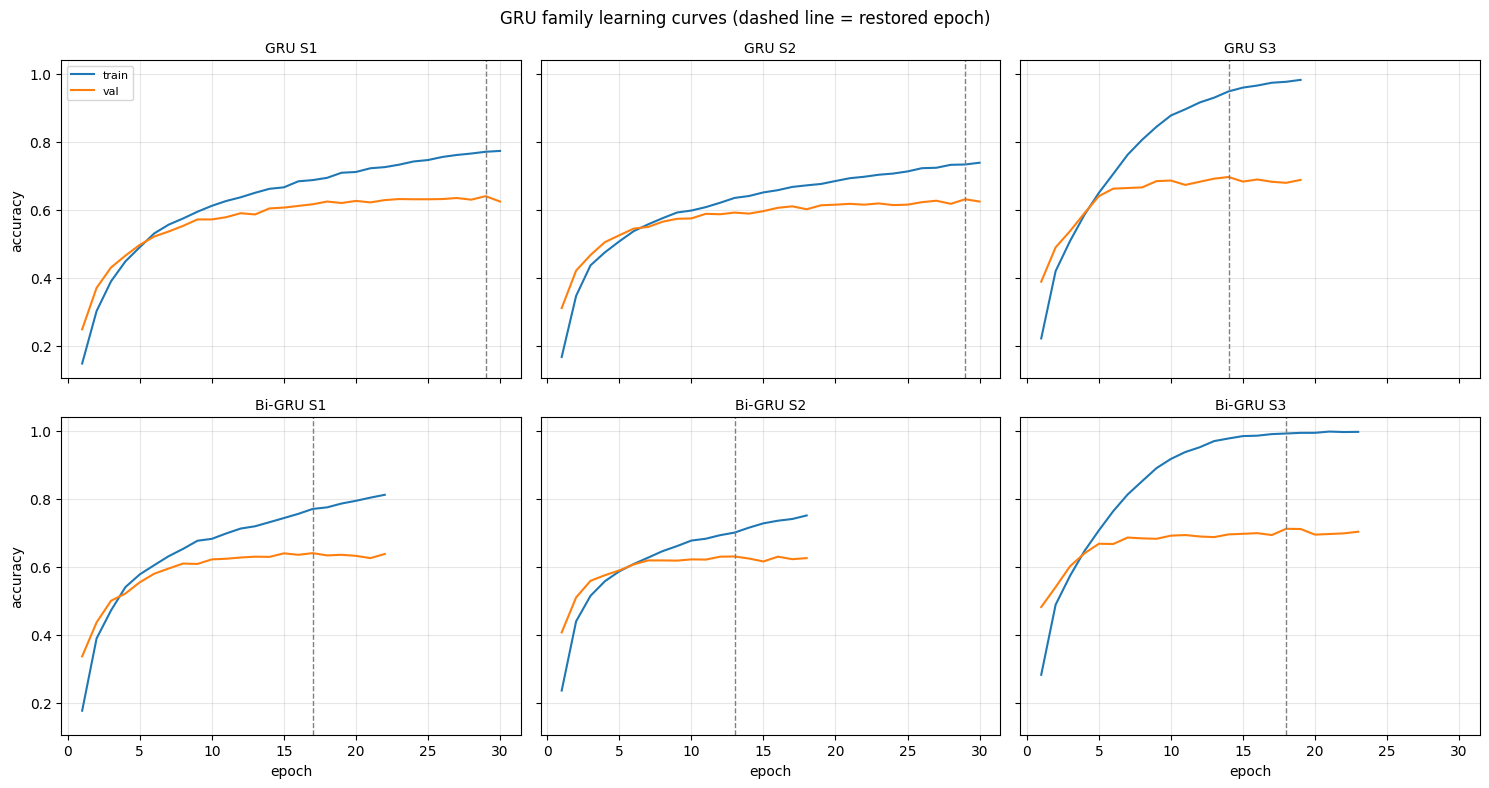

runs that reached the 30-epoch cap without early stopping: ['GRU_S1', 'GRU_S2']


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for row, model_name in enumerate(["GRU", "Bi-GRU"]):
    for col, cfg_id in enumerate(["S1", "S2", "S3"]):
        h = HISTORIES[f"{model_name}_{cfg_id}"]
        ax = axes[row, col]
        ax.plot(range(1, len(h["accuracy"]) + 1), h["accuracy"], label="train")
        ax.plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], label="val")
        ax.axvline(int(np.argmax(h["val_accuracy"])) + 1, ls="--", lw=1, c="grey")
        ax.set_title(f"{model_name} {cfg_id}", fontsize=10)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel("accuracy")
        if row == 1:
            ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=8)
fig.suptitle("GRU family learning curves (dashed line = restored epoch)", fontsize=12)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

capped = [rid for rid, h in HISTORIES.items() if len(h["loss"]) >= EPOCHS]
print(f"runs that reached the {EPOCHS}-epoch cap without early stopping: "
      f"{capped if capped else 'none'}")

### Embedding contrast

S1 against S2 holds units, dropout and the frozen flag fixed. Only the embedding
source changes, so the difference is attributable.

The prediction was that Word2Vec would win everywhere. It covers the full vocabulary
against GloVe's 87.3%, and the missing 12.7% are the newsgroup-specific technical
tokens where topic signal concentrates.

The result splits by architecture:

| Model | S1 GloVe | S2 Word2Vec | Winner |
| --- | --- | --- | --- |
| SimpleRNN | 0.2853 | 0.3351 | Word2Vec +0.0498 |
| Bi-SimpleRNN | 0.3880 | 0.4114 | Word2Vec +0.0234 |
| GRU | 0.6287 | 0.6131 | GloVe +0.0156 |
| Bi-GRU | 0.6270 | 0.6104 | GloVe +0.0166 |
| LSTM | 0.6120 | 0.6094 | GloVe +0.0026 |
| Bi-LSTM | 0.6378 | 0.6130 | GloVe +0.0248 |

Both ungated models prefer Word2Vec. All four gated models prefer GloVe.

Coverage and quality are different things. Word2Vec covers every word but was trained
on roughly 9,000 documents, so each vector rests on little evidence. GloVe covers
87.3% but was estimated from six billion tokens of general English.

The SimpleRNN cannot carry information across long distances. It leans on individual
token identity, so full coverage helps it most and a noisy vector still beats no
vector. The gated models build context across the sequence. They can exploit the finer
semantic structure in the better-estimated vectors, and they lose little from GloVe's
missing 12.7% because surrounding words supply what a zero vector does not.

S2 against S3 is the largest jump in the grid. That suggests the frozen embedding, not
the cell type, was the binding constraint.

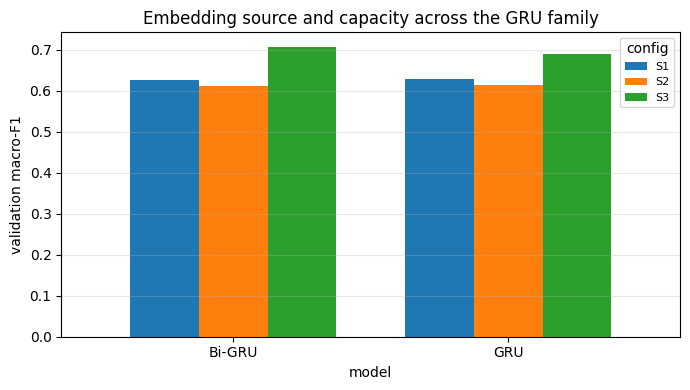

GRU      S1 glove 0.6287 -> S2 word2vec 0.6131  delta -0.0156
Bi-GRU   S1 glove 0.6270 -> S2 word2vec 0.6104  delta -0.0166


In [ ]:
runs = pd.read_csv(RUNS_CSV)
seq_runs = runs[runs.model.isin(["GRU", "Bi-GRU"])]

pivot = seq_runs.pivot_table(index="model", columns="config", values="val_macro_f1")
fig, ax = plt.subplots(figsize=(7, 4))
pivot[["S1", "S2", "S3"]].plot(kind="bar", ax=ax, rot=0, width=0.75)
ax.set_ylabel("validation macro-F1")
ax.set_title("Embedding source and capacity across the GRU family")
ax.legend(title="config", fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_embedding_contrast.png", dpi=150, bbox_inches="tight")
plt.show()

for m in ["GRU", "Bi-GRU"]:
    s1 = pivot.loc[m, "S1"]
    s2 = pivot.loc[m, "S2"]
    print(f"{m:8s} S1 glove {s1:.4f} -> S2 word2vec {s2:.4f}  "
          f"delta {s2 - s1:+.4f}")

## Validation leaderboard

Configurations are selected on the highest validation macro-F1, not accuracy. With 20
classes and an imbalanced test split, macro-F1 weights every class equally, so a model
cannot score well by doing well only on the largest groups.

The test set is untouched to this point.

   run_id  model config embedding  units  dropout  trainable_emb  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
Bi-GRU_S3 Bi-GRU     S3  word2vec    128      0.5           True          23          18      0.711574      0.706949          89.9
   GRU_S3    GRU     S3  word2vec    128      0.5           True          19          14      0.696877      0.688791          51.7
   GRU_S1    GRU     S1     glove     64      0.3          False          30          29      0.640539      0.628668          71.6
Bi-GRU_S1 Bi-GRU     S1     glove     64      0.3          False          22          17      0.639927      0.627035          81.8
   GRU_S2    GRU     S2  word2vec     64      0.3          False          30          29      0.631353      0.613096          90.1
Bi-GRU_S2 Bi-GRU     S2  word2vec     64      0.3          False          18          13      0.630129      0.610408          65.1

best GRU      -> S3  (val macro-F1 0.6888, val acc 0.6969)
best Bi-GRU   -> S3  (v

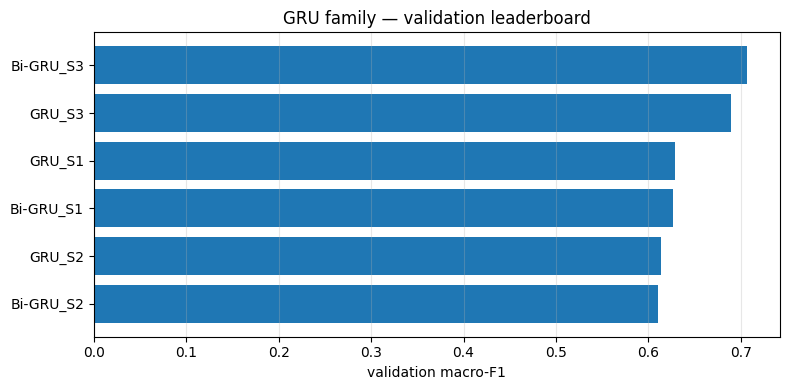

In [ ]:
runs = pd.read_csv(RUNS_CSV)
seq_runs = runs[runs.model.isin(["GRU", "Bi-GRU"])].copy()

board = ev.leaderboard(seq_runs, by="val_macro_f1")
print(board[["run_id", "model", "config", "embedding", "units", "dropout",
             "trainable_emb", "epochs_run", "best_epoch",
             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))

BEST_SEQ = {}
for m in ["GRU", "Bi-GRU"]:
    sub = seq_runs[seq_runs.model == m]
    BEST_SEQ[m] = sub.loc[sub.val_macro_f1.idxmax(), "config"]

print()
for m, c in BEST_SEQ.items():
    r = seq_runs[(seq_runs.model == m) & (seq_runs.config == c)].iloc[0]
    print(f"best {m:8s} -> {c}  (val macro-F1 {r.val_macro_f1:.4f}, "
          f"val acc {r.val_accuracy:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(board.run_id, board.val_macro_f1)
ax.invert_yaxis()
ax.set_xlabel("validation macro-F1")
ax.set_title("GRU family — validation leaderboard")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_val_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Test evaluation

Only the winning configuration of each model goes to test, and only once.

The architecture is rebuilt from the frozen grid and the saved weights are reloaded. No
model object is reused from memory, so this reproduces on a fresh runtime from the saved
artifacts alone.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
TEST_RESULTS = {}
TEST_PREDS = {}

for model_name, cfg_id in BEST_SEQ.items():
    cfg = SEQ_GRID[cfg_id]
    run_id = f"{model_name}_{cfg_id}"

    keras.backend.clear_session()
    gc.collect()
    model = build_sequence_model(
        cell=layers.GRU,
        embedding_matrix=EMB[cfg["embedding"]],
        units=cfg["units"], dropout=cfg["dropout"],
        trainable_emb=cfg["trainable_emb"],
        bidirectional=(model_name == "Bi-GRU"),
    )
    model.load_weights(DIRS["gru/weights"] / f"{run_id}.weights.h5")

    test_probs = model.predict(X_test_seq, verbose=0)
    res = ev.evaluate_model(y_test, test_probs, CLASSES, SUPERCLASS,
                            model_name=f"{model_name} {cfg_id}", split="test")
    TEST_RESULTS[f"{model_name} {cfg_id}"] = res
    TEST_PREDS[f"{model_name} {cfg_id}"] = ev.to_labels(test_probs)

    ev.save_result(res, DIRS["gru/reports"], f"test_{model_name}_{cfg_id}")

    row = runs[runs.run_id == run_id].iloc[0].to_dict()
    row.update({"test_accuracy": res["accuracy"],
                "test_macro_f1": res["macro_f1"],
                "test_weighted_f1": res["weighted_f1"],
                "notes": "required run | best config, evaluated on test"})
    ev.log_run(RUNS_CSV, row)
    print()

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


GRU S3  [test]
  accuracy    : 0.6304
  macro-F1    : 0.6214
  weighted-F1 : 0.6320
  errors      : 2,684 (1,016 within-family = 37.9%, 1,668 cross-family = 62.1%)
logged GRU_S3 -> runs_zawad.csv (6 rows)



/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Bi-GRU S3  [test]
  accuracy    : 0.6409
  macro-F1    : 0.6304
  weighted-F1 : 0.6413
  errors      : 2,608 (999 within-family = 38.3%, 1,609 cross-family = 61.7%)
logged Bi-GRU_S3 -> runs_zawad.csv (6 rows)



### Classification reports

Printed in full. The brief requires a full classification report per model, and a cell
without visible output cannot be verified.

The saved JSON in `results/zawad/gru/reports/` holds the same numbers in
machine-readable form for whoever assembles the consolidated table.

In [ ]:
for name, res in TEST_RESULTS.items():
    print("="*72)
    print(f"{name}  [test]")
    print("="*72)
    print(res["report_str"])

GRU S3  [test]
                          precision    recall  f1-score   support

             alt.atheism     0.4928    0.2201    0.3043       309
           comp.graphics     0.5990    0.6257    0.6120       382
 comp.os.ms-windows.misc     0.5569    0.5937    0.5747       379
comp.sys.ibm.pc.hardware     0.5124    0.6458    0.5714       384
   comp.sys.mac.hardware     0.7738    0.5285    0.6280       369
          comp.windows.x     0.7243    0.6333    0.6758       390
            misc.forsale     0.5806    0.7639    0.6598       377
               rec.autos     0.6716    0.6131    0.6410       367
         rec.motorcycles     0.7375    0.6527    0.6925       383
      rec.sport.baseball     0.7932    0.8080    0.8005       375
        rec.sport.hockey     0.8615    0.8660    0.8638       388
               sci.crypt     0.7629    0.7082    0.7345       377
         sci.electronics     0.4863    0.5132    0.4994       380
                 sci.med     0.7747    0.6623    0.7141     

### Confusion matrices and per-class F1

Row-normalised. A bright off-diagonal cell means a class is losing a large share of
its own documents, not that the class is large.

The structure is block-shaped, which shows the errors are semantic and not random.
Bi-GRU's largest confusions are `comp.windows.x` losing 19.2% to
`comp.os.ms-windows.misc`, and `comp.sys.mac.hardware` losing 17.1% to
`comp.sys.ibm.pc.hardware`.

BERT roughly halves both, to 9.0% and 8.6%. That is the contextual embedding advantage
showing up where vocabulary overlap is highest.

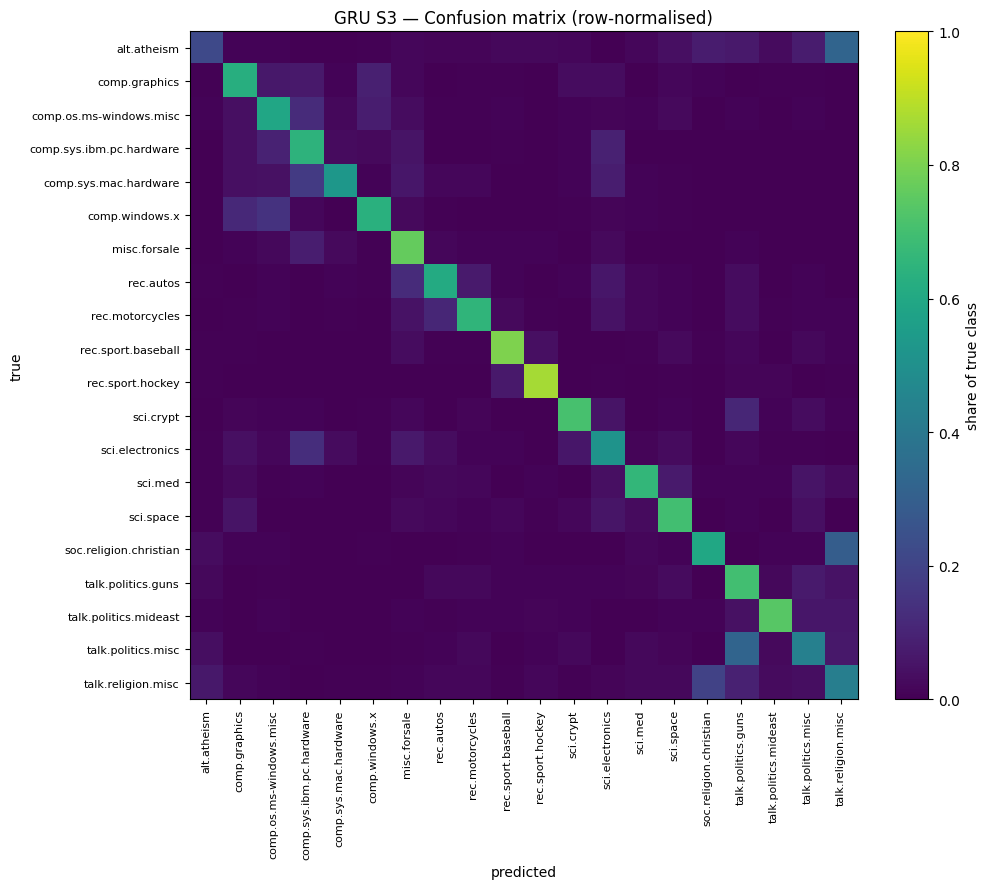

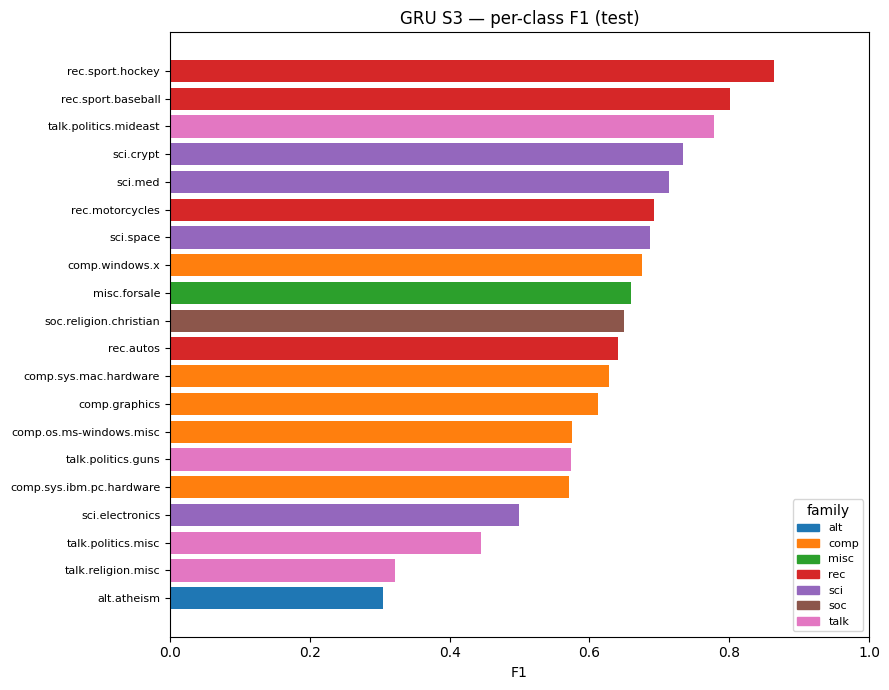

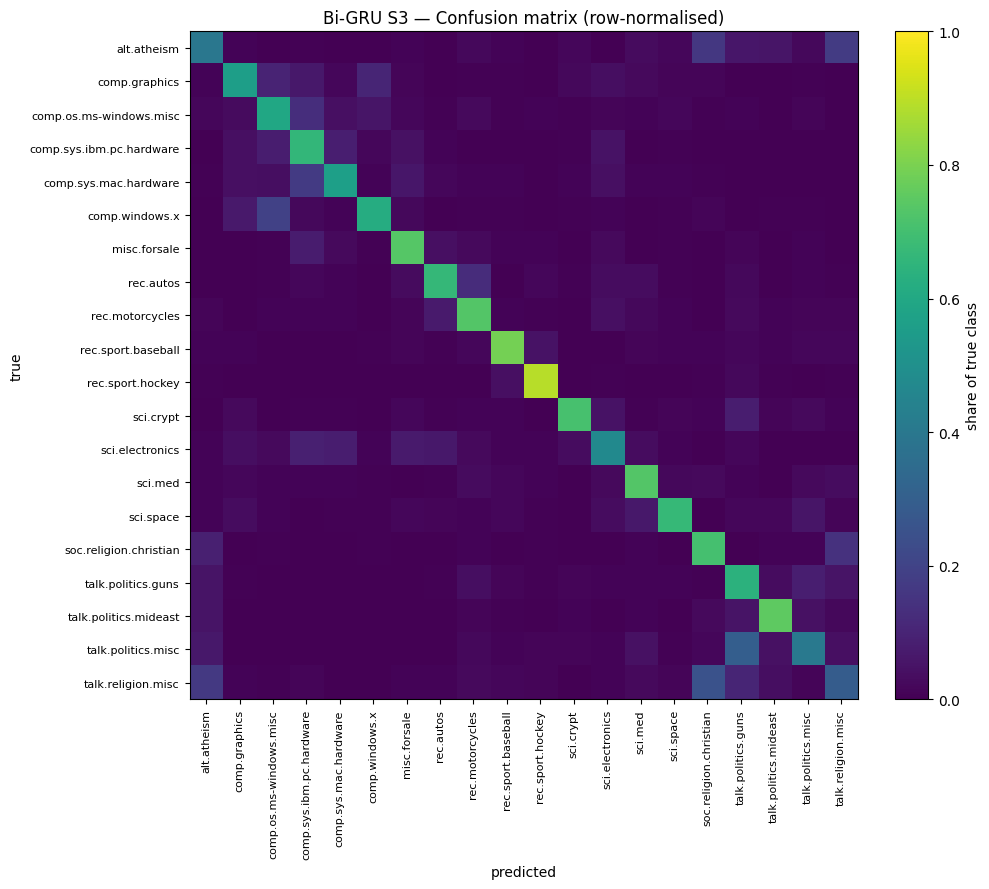

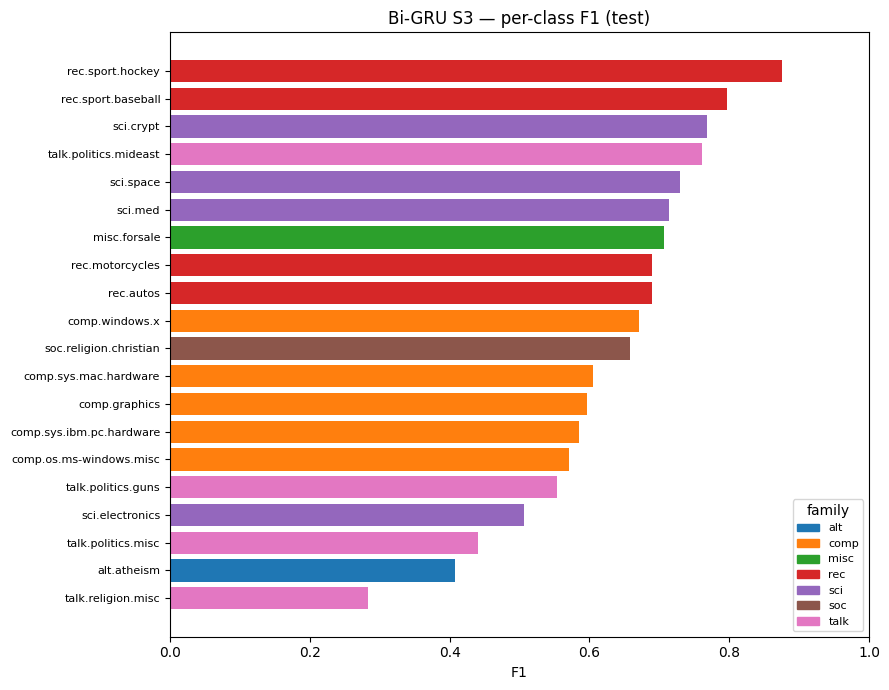

In [ ]:
for name, res in TEST_RESULTS.items():
    stem = name.replace(" ", "_")
    ev.plot_confusion_matrix(res, CLASSES,
                             save_path=DIRS["fig/gru"] / f"cm_{stem}.png")
    plt.show()
    ev.plot_per_class_f1(res, save_path=DIRS["fig/gru"] / f"f1_{stem}.png")
    plt.show()

### Where the errors fall

The 20 labels group into 7 families, so a misclassification splits into two kinds.
Confusing two `comp.sys.*` groups is a fine-grained failure between similar topics.
Confusing one with `talk.politics.guns` is a failure at topic identification.

If errors were random across the other 19 labels, about 15% would land within-family.
Observed: GRU 37.9%, Bi-GRU 38.3%, BERT 39.9%. Every model runs about two and a half
times the chance rate. BERT is highest, meaning it clears the easy cross-family errors
and what remains sits in genuinely confusable pairs.

One caveat on the metric. `alt.atheism`, `soc.religion.christian` and
`talk.religion.misc` sit in three different families but are the most semantically
adjacent trio in the dataset. Four of BERT's five largest confusions are among them.
They count as cross-family, so the 60% figure overstates the failure.

GRU S3
  errors        : 2,684
  within-family : 1,016 (37.9%)
  cross-family  : 1,668 (62.1%)

Bi-GRU S3
  errors        : 2,608
  within-family : 999 (38.3%)
  cross-family  : 1,609 (61.7%)

Most frequent confusions — Bi-GRU S3
                   true                predicted  count  pct_of_true_class  same_family
     talk.politics.misc       talk.politics.guns     90             0.2980         True
         comp.windows.x  comp.os.ms-windows.misc     75             0.1923         True
  comp.sys.mac.hardware comp.sys.ibm.pc.hardware     63             0.1707         True
     talk.religion.misc   soc.religion.christian     61             0.2510        False
 soc.religion.christian       talk.religion.misc     55             0.1432        False
            alt.atheism       talk.religion.misc     54             0.1748        False
            alt.atheism   soc.religion.christian     50             0.1618        False
comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     50           

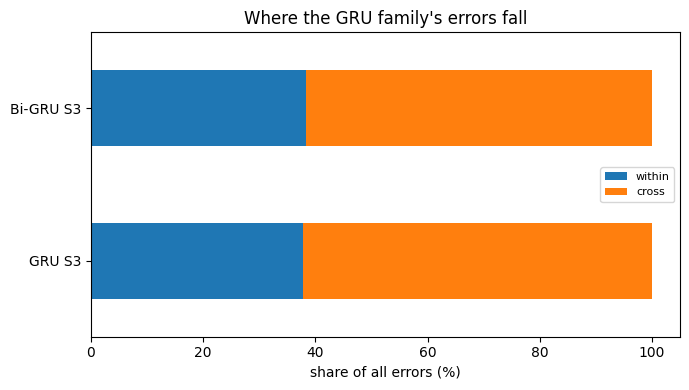

In [ ]:
for name, res in TEST_RESULTS.items():
    f = res["family"]
    print(f"{name}")
    print(f"  errors        : {f['n_errors']:,}")
    print(f"  within-family : {f['within_family']:,} ({f['within_share']:.1%})")
    print(f"  cross-family  : {f['cross_family']:,} ({f['cross_share']:.1%})")
    print()

best_seq_name = max(TEST_RESULTS, key=lambda k: TEST_RESULTS[k]["macro_f1"])
print("="*72)
print(f"Most frequent confusions — {best_seq_name}")
print("="*72)
print(ev.top_confusions(y_test, TEST_PREDS[best_seq_name],
                        CLASSES, SUPERCLASS, k=12).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
fam = pd.DataFrame({
    n: {"within": r["family"]["within_share"] * 100,
        "cross":  r["family"]["cross_share"] * 100}
    for n, r in TEST_RESULTS.items()
}).T
fam.plot(kind="barh", stacked=True, ax=ax)
ax.set_xlabel("share of all errors (%)")
ax.set_title("Where the GRU family's errors fall")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_family_error_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 10: BERT Base

TensorFlow is released before PyTorch is imported. Both frameworks share one T4.
Memory growth was enabled in section 0, but the six recurrent models left allocations
behind. Clearing the Keras session and collecting returns that memory so `Trainer`
starts on a clean card.

In [ ]:
keras.backend.clear_session()
for _v in ["_demo"]:
    if _v in globals():
        del globals()[_v]
gc.collect()

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          set_seed as hf_set_seed)
import transformers

hf_set_seed(SEED)

print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"cuda         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device       : {torch.cuda.get_device_name(0)}")
    print(f"vram total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"vram in use  : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

torch        : 2.11.0+cu128
transformers : 5.15.0
cuda         : True
device       : Tesla T4
vram total   : 15.6 GB
vram in use  : 0.00 GB


### Input text and why it differs from the recurrent tier

BERT reads `text_raw`. The recurrent models read `text_clean`. This is a deliberate
choice and needs stating plainly, because otherwise it looks like an oversight.

`text_clean` is lowercased, stopword-stripped and lemmatised. Those steps help a
50-dimensional embedding with a small recurrent cell. They shrink the vocabulary and
drop tokens that carry little signal for that kind of model.

They hurt BERT. Casing, punctuation and function words are the surface structure
WordPiece and the positional encodings were pretrained on. Stripping them throws away
information the pretrained weights already know how to use.

The usual objection to raw text on this dataset is metadata leakage, where models
learn email signatures instead of topic. That does not apply. The SetFit build already
removed headers, footers and quoted replies. The measurement below confirms it.

In [ ]:
leak = {
    "contains 'From:'":     train_df.text_raw.str.contains("From:").mean(),
    "contains 'Subject:'":  train_df.text_raw.str.contains("Subject:").mean(),
    "contains quoted '>'":  train_df.text_raw.str.contains("\n>").mean(),
}
for k, v in leak.items():
    print(f"{k:24s} {v:.1%} of training documents")

print()
print("text_clean (RNN input):")
print(f"  {train_df.text_clean.iloc[0][:150]!r}")
print()
print("text_raw (BERT input):")
print(f"  {train_df.text_raw.iloc[0][:150]!r}")

contains 'From:'         1.1% of training documents
contains 'Subject:'      0.8% of training documents
contains quoted '>'      0.0% of training documents

text_clean (RNN input):
  'yes say absolutey true fail mention fact lciii us new pin simms allow bite access simm case iii one simm slot access bite wides view express post indi'

text_raw (BERT input):
  'Yes! what you are saying is absolutey true, but what you fail to mention is the\nfact that the LCIII uses the new 72 pin simms which allow 32 bit acces'


### Sequence length

`max_len` comes from a measurement, not a default. The lab template uses 128. The
distribution below shows that would discard half the corpus.

Attention cost grows with the square of sequence length, so 512 costs well over twice
what 256 costs. On a T4 with a session limit, three configurations at 512 leaves no
slack for a disconnect. 256 covers the median document twice over and truncates about
a quarter of the corpus. Section 10b measures what that quarter is worth.

One point for the report. The recurrent models read 250 tokens of cleaned text.
Cleaning removes roughly half the tokens, so 250 clean tokens spans more of the
original document than 256 WordPiece tokens does. BERT is not getting a longer view
than the RNNs. It is getting a shorter one.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2604 > 512). Running this sequence through the model will result in indexing errors


WordPiece token counts on text_raw (train, n=9,249)
  median 130  mean 355  p90 486  max 51937
  tokens per word: 1.88

  max_len 128 -> 50.4% truncated
  max_len 256 -> 24.4% truncated
  max_len 384 -> 13.9% truncated
  max_len 512 -> 9.1% truncated

chosen: max_len 256 (24.4% truncated)


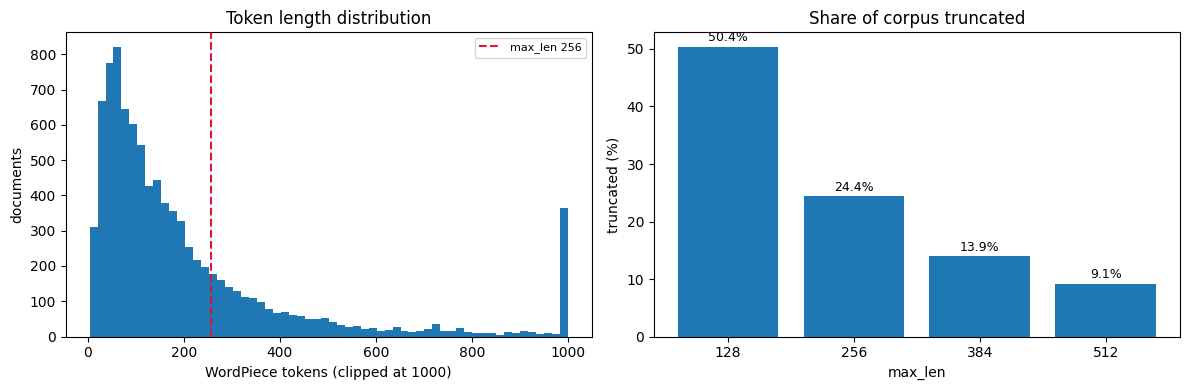

In [ ]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

_full = tokenizer(train_df.text_raw.tolist(), truncation=False)["input_ids"]
tok_lens = np.array([len(x) for x in _full])

print(f"WordPiece token counts on text_raw (train, n={len(tok_lens):,})")
print(f"  median {int(np.median(tok_lens))}  mean {int(tok_lens.mean())}  "
      f"p90 {int(np.percentile(tok_lens, 90))}  max {int(tok_lens.max())}")
print(f"  tokens per word: {tok_lens.mean() / train_df.text_raw.str.split().str.len().mean():.2f}")
print()
trunc = {}
for L in (128, 256, 384, 512):
    trunc[L] = float((tok_lens > L).mean())
    print(f"  max_len {L:3d} -> {trunc[L]:.1%} truncated")

MAX_LEN_BERT = 256
print(f"\nchosen: max_len {MAX_LEN_BERT} ({trunc[MAX_LEN_BERT]:.1%} truncated)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(tok_lens, 0, 1000), bins=60)
axes[0].axvline(MAX_LEN_BERT, color="crimson", ls="--", label=f"max_len {MAX_LEN_BERT}")
axes[0].set_xlabel("WordPiece tokens (clipped at 1000)")
axes[0].set_ylabel("documents")
axes[0].set_title("Token length distribution")
axes[0].legend(fontsize=8)
axes[1].bar([str(k) for k in trunc], [v * 100 for v in trunc.values()])
axes[1].set_xlabel("max_len")
axes[1].set_ylabel("truncated (%)")
axes[1].set_title("Share of corpus truncated")
for i, v in enumerate(trunc.values()):
    axes[1].text(i, v * 100 + 1, f"{v:.1%}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(DIRS["fig/bert"] / "bert_truncation.png", dpi=150, bbox_inches="tight")
plt.show()

### Configurations

The S1, S2, S3 axis means nothing for BERT. The embedding is not a choice, and there is
no frozen against trainable decision because fine-tuning updates all 110 million
parameters by design.

So BERT gets three configurations on learning rate, the axis that decides fine-tuning
outcomes.

| Config | Learning rate | Epochs | Batch |
| --- | --- | --- | --- |
| B1 | 2e-5 | 3 | 16 |
| B2 | 3e-5 | 3 | 16 |
| B3 | 5e-5 | 4 | 32 |

The 2e-5 to 5e-5 range is what the original BERT paper reports for fine-tuning. It sits
three orders of magnitude below the 1e-3 used for the recurrent models because the
pretrained weights are already good, and a large step destroys knowledge that cost
nothing to acquire. The same reasoning explains warmup, gradient clipping and the low
epoch count.

B3 moves batch size and epochs alongside the learning rate, so it is not a
single-variable comparison against B1 and B2 and is not read as one.

`fp16` is used, not `bf16`. The T4 is a Turing card with no bfloat16 support.
`transformers` 5.x expects `warmup_steps` rather than `warmup_ratio`, so the ratio is
converted at call time and the derived step count is printed with each run.

In [ ]:
BERT_GRID = {
    "B1": {"learning_rate": 2e-5, "epochs": 3, "batch_size": 16},
    "B2": {"learning_rate": 3e-5, "epochs": 3, "batch_size": 16},
    "B3": {"learning_rate": 5e-5, "epochs": 4, "batch_size": 32},
}
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

print(pd.DataFrame(BERT_GRID).T.to_string())
print(f"\nmax_len {MAX_LEN_BERT} | warmup_ratio {WARMUP_RATIO} | "
      f"weight_decay {WEIGHT_DECAY} | fp16 True | seed {SEED}")

    learning_rate  epochs  batch_size
B1        0.00002     3.0        16.0
B2        0.00003     3.0        16.0
B3        0.00005     4.0        32.0

max_len 256 | warmup_ratio 0.1 | weight_decay 0.01 | fp16 True | seed 42


### Dataset and metrics

Tokenised once with truncation and no padding. `DataCollatorWithPadding` pads each
batch to its own longest member instead of to `max_len`. That is meaningfully faster
here, since the median document is 130 tokens against a 256 ceiling.

`compute_metrics` returns macro-F1 alongside accuracy. The default `Trainer` example
reports accuracy only. Every other model in this project is selected on macro-F1, and
the rule has to be identical across all ten.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score


class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = int(self.labels[idx])
        return item


def encode(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LEN_BERT)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro",
                             labels=list(range(NUM_CLASSES)), zero_division=0),
    }


enc_train = encode(train_df.text_raw)
enc_val   = encode(val_df.text_raw)
enc_test  = encode(test_df.text_raw)

ds_train = NewsDataset(enc_train, y_train)
ds_val   = NewsDataset(enc_val,   y_val)
ds_test  = NewsDataset(enc_test,  y_test)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"tokenised  : train {len(ds_train):,}  val {len(ds_val):,}  test {len(ds_test):,}")
print(f"sample len : {len(ds_train[0]['input_ids'])} tokens (before batch padding)")
print(f"metrics    : accuracy, macro_f1")

tokenised  : train 9,249  val 1,633  test 7,262
sample len : 256 tokens (before batch padding)
metrics    : accuracy, macro_f1


### Fine-tuning loop

`load_best_model_at_end` with `metric_for_best_model="macro_f1"` does the same job as
`restore_best_weights=True` in the recurrent models. Both tiers are selected the same
way.

Checkpoints go to local Colab disk with `save_total_limit=1`, never to Drive. A
`bert-base` checkpoint is about 420 MB and three configurations would push over a
gigabyte. Only the winner is copied to Drive at the end of this section.

Each row is written to `runs_zawad.csv` as its configuration finishes.

In [ ]:
BERT_HISTORIES = {}


def run_bert(config_id, notes="required run", max_len_override=None,
             run_id_override=None):
    cfg = BERT_GRID[config_id]
    run_id = run_id_override or f"BERT_{config_id}"
    max_len = max_len_override or MAX_LEN_BERT

    if max_len_override:
        ds_tr = NewsDataset(tokenizer(list(train_df.text_raw), truncation=True,
                                      max_length=max_len), y_train)
        ds_va = NewsDataset(tokenizer(list(val_df.text_raw), truncation=True,
                                      max_length=max_len), y_val)
    else:
        ds_tr, ds_va = ds_train, ds_val

    steps_per_epoch = int(np.ceil(len(ds_tr) / cfg["batch_size"]))
    total_steps = steps_per_epoch * cfg["epochs"]
    warmup_steps = int(WARMUP_RATIO * total_steps)

    hf_set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES)

    args = TrainingArguments(
        output_dir=str(BERT_SCRATCH / run_id),
        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=64,
        num_train_epochs=cfg["epochs"],
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        max_grad_norm=1.0,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=ds_tr, eval_dataset=ds_va,
        data_collator=collator, compute_metrics=compute_metrics,
    )

    print(f"\n{'='*66}\n{run_id}  |  lr {cfg['learning_rate']}  "
          f"epochs {cfg['epochs']}  batch {cfg['batch_size']}  max_len {max_len}"
          f"\n{'='*66}")
    print(f"  {steps_per_epoch} steps/epoch, {total_steps} total, "
          f"warmup {warmup_steps} steps ({WARMUP_RATIO:.0%})")

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    evals = [h for h in trainer.state.log_history if "eval_macro_f1" in h]
    BERT_HISTORIES[run_id] = evals
    best_epoch = int(np.argmax([h["eval_macro_f1"] for h in evals])) + 1
    best = evals[best_epoch - 1]

    val_logits = trainer.predict(ds_va).predictions
    if isinstance(val_logits, tuple):
        val_logits = val_logits[0]
    res_val = ev.evaluate_model(y_val, val_logits, CLASSES, SUPERCLASS,
                                model_name=f"BERT-Base {config_id}", split="val")

    with open(DIRS["bert/history"] / f"{run_id}.json", "w") as fh:
        json.dump(evals, fh, indent=2)

    ev.log_run(RUNS_CSV, {
        "run_id": run_id, "owner": OWNER, "notebook": NOTEBOOK,
        "tier": "transformer",
        "model": "BERT-Base", "config": config_id,
        "embedding": "wordpiece", "units": np.nan, "dropout": np.nan,
        "trainable_emb": True,
        "batch_size": cfg["batch_size"], "learning_rate": cfg["learning_rate"],
        "epochs_run": cfg["epochs"], "best_epoch": best_epoch,
        "n_params": int(sum(p.numel() for p in model.parameters())),
        "hyperparams": json.dumps({"max_len": max_len,
                                   "warmup_ratio": WARMUP_RATIO,
                                   "warmup_steps": warmup_steps,
                                   "weight_decay": WEIGHT_DECAY,
                                   "max_grad_norm": 1.0,
                                   "fp16": True,
                                   "base_model": MODEL_NAME}),
        "val_loss": float(best["eval_loss"]),
        "val_accuracy": res_val["accuracy"], "val_macro_f1": res_val["macro_f1"],
        "test_accuracy": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
        "train_time_s": round(train_time, 1),
        "dataset_checksum": CHECKSUM_TRAIN,
        "notes": notes,
    })

    print(f"{run_id}: best epoch {best_epoch}, {train_time/60:.1f} min")
    return trainer


print(f"BERT harness ready (transformers {transformers.__version__})")
print(f"warmup_ratio {WARMUP_RATIO:.0%} converted to warmup_steps at call time")

BERT harness ready (transformers 5.15.0)
warmup_ratio 10% converted to warmup_steps at call time


In [ ]:
TRAINERS = {}
for cfg_id in ["B1", "B2", "B3"]:
    TRAINERS[cfg_id] = run_bert(cfg_id)
    torch.cuda.empty_cache()
    gc.collect()

print("\n" + "="*66)
print("BERT grid complete — 9 of 9 required runs done")
print(pd.read_csv(RUNS_CSV)[["run_id", "model", "config", "epochs_run",
                             "best_epoch", "val_accuracy", "val_macro_f1",
                             "train_time_s"]].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT_B1  |  lr 2e-05  epochs 3  batch 16  max_len 256
  579 steps/epoch, 1737 total, warmup 173 steps (10%)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.832590,0.989131,0.714023,0.683639
2,0.811163,0.827260,0.748316,0.724518
3,0.541654,0.789958,0.767912,0.746305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT-Base B3  [val]
  accuracy    : 0.7832
  macro-F1    : 0.7753
  weighted-F1 : 0.7849
  errors      : 354 (135 within-family = 38.1%, 219 cross-family = 61.9%)
logged BERT_B3 -> runs_zawad.csv (9 rows)
BERT_B3: best epoch 4, 10.0 min

BERT grid complete — 9 of 9 required runs done
   run_id     model config  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
   GRU_S1       GRU     S1          30          29      0.640539      0.628668          71.6
   GRU_S2       GRU     S2          30          29      0.631353      0.613096          90.1
Bi-GRU_S1    Bi-GRU     S1          22          17      0.639927      0.627035          81.8
Bi-GRU_S2    Bi-GRU     S2          18          13      0.630129      0.610408          65.1
   GRU_S3       GRU     S3          19          14      0.696877      0.688791          51.7
Bi-GRU_S3    Bi-GRU     S3          23          18      0.711574      0.706949          89.9
  BERT_B1 BERT-Base     B1           3           3      0.767912

### Selection and test evaluation

Same rule as everywhere else in the project. Highest validation macro-F1, evaluated
once on test.

 run_id  learning_rate  batch_size  epochs_run  best_epoch  val_loss  val_accuracy  val_macro_f1  train_time_s
BERT_B1        0.00002          16           3           3  0.789958      0.767912      0.746305         432.7
BERT_B2        0.00003          16           3           3  0.778914      0.777710      0.762659         472.7
BERT_B3        0.00005          32           4           4  0.782371      0.783221      0.775260         602.4

best BERT config -> B3


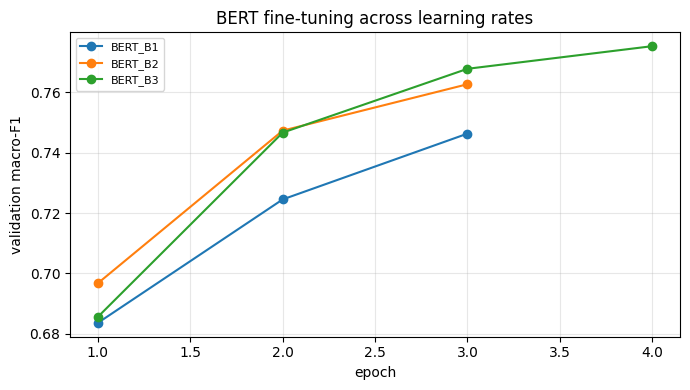

In [ ]:
runs = pd.read_csv(RUNS_CSV)
bert_runs = runs[runs.model == "BERT-Base"]
BEST_BERT = bert_runs.loc[bert_runs.val_macro_f1.idxmax(), "config"]

print(bert_runs[["run_id", "learning_rate", "batch_size", "epochs_run",
                 "best_epoch", "val_loss", "val_accuracy", "val_macro_f1",
                 "train_time_s"]].to_string(index=False))
print(f"\nbest BERT config -> {BEST_BERT}")

fig, ax = plt.subplots(figsize=(7, 4))
for rid, evals in BERT_HISTORIES.items():
    ax.plot([h["epoch"] for h in evals], [h["eval_macro_f1"] for h in evals],
            marker="o", label=rid)
ax.set_xlabel("epoch")
ax.set_ylabel("validation macro-F1")
ax.set_title("BERT fine-tuning across learning rates")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["fig/bert"] / "bert_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
best_trainer = TRAINERS[BEST_BERT]

test_logits = best_trainer.predict(ds_test).predictions
res_bert = ev.evaluate_model(y_test, test_logits, CLASSES, SUPERCLASS,
                             model_name=f"BERT-Base {BEST_BERT}", split="test")

TEST_RESULTS[f"BERT-Base {BEST_BERT}"] = res_bert
TEST_PREDS[f"BERT-Base {BEST_BERT}"] = ev.to_labels(test_logits)

ev.save_result(res_bert, DIRS["bert/reports"], f"test_BERT-Base_{BEST_BERT}")

row = runs[runs.run_id == f"BERT_{BEST_BERT}"].iloc[0].to_dict()
row.update({"test_accuracy": res_bert["accuracy"],
            "test_macro_f1": res_bert["macro_f1"],
            "test_weighted_f1": res_bert["weighted_f1"],
            "notes": "required run | best config, evaluated on test"})
ev.log_run(RUNS_CSV, row)

print()
print(res_bert["report_str"])

BERT-Base B3  [test]
  accuracy    : 0.7345
  macro-F1    : 0.7225
  weighted-F1 : 0.7350
  errors      : 1,928 (770 within-family = 39.9%, 1,158 cross-family = 60.1%)
logged BERT_B3 -> runs_zawad.csv (9 rows)

                          precision    recall  f1-score   support

             alt.atheism     0.4966    0.4790    0.4876       309
           comp.graphics     0.7306    0.7382    0.7344       382
 comp.os.ms-windows.misc     0.6938    0.6755    0.6845       379
comp.sys.ibm.pc.hardware     0.6721    0.6406    0.6560       384
   comp.sys.mac.hardware     0.7098    0.7886    0.7471       369
          comp.windows.x     0.8508    0.7897    0.8191       390
            misc.forsale     0.8455    0.8568    0.8511       377
               rec.autos     0.8274    0.7575    0.7909       367
         rec.motorcycles     0.7730    0.7911    0.7819       383
      rec.sport.baseball     0.9091    0.8800    0.8943       375
        rec.sport.hockey     0.9162    0.9304    0.9233       

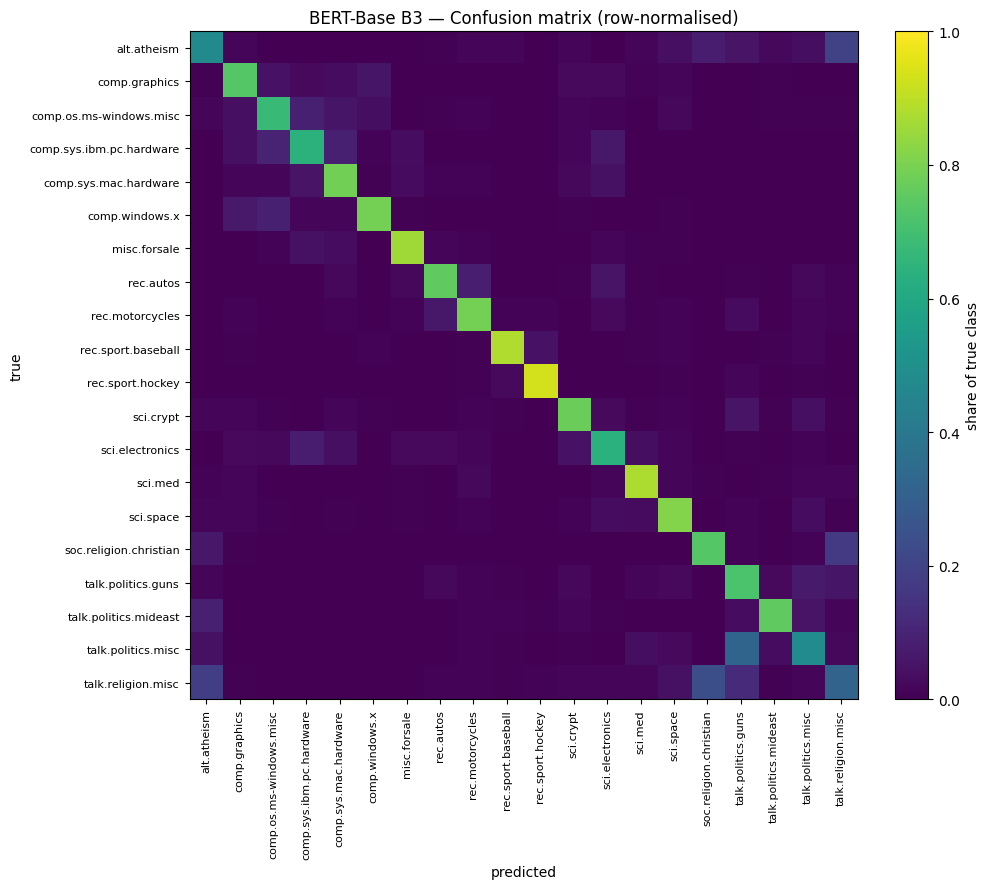

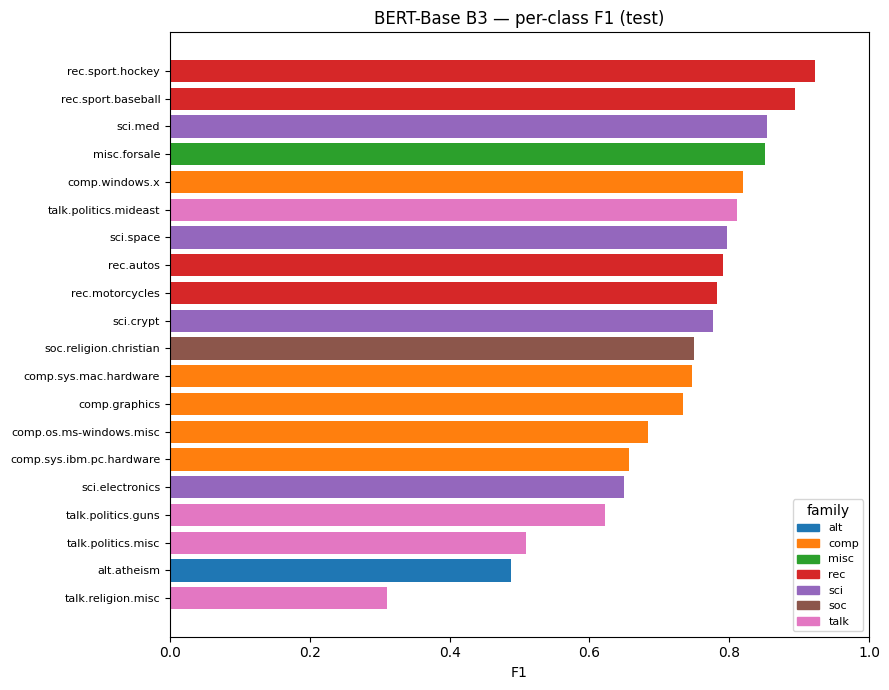

BERT-Base B3 error structure
  errors        : 1,928
  within-family : 770 (39.9%)
  cross-family  : 1,158 (60.1%)

                    true                predicted  count  pct_of_true_class  same_family
      talk.politics.misc       talk.politics.guns     97             0.3212         True
  soc.religion.christian       talk.religion.misc     65             0.1693        False
             alt.atheism       talk.religion.misc     61             0.1974        False
      talk.religion.misc   soc.religion.christian     58             0.2387        False
      talk.religion.misc              alt.atheism     45             0.1852        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     36             0.0938         True
          comp.windows.x  comp.os.ms-windows.misc     35             0.0897         True
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     34             0.0897         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     33             0.0859        

In [ ]:
ev.plot_confusion_matrix(res_bert, CLASSES,
                         save_path=DIRS["fig/bert"] / f"cm_BERT-Base_{BEST_BERT}.png")
plt.show()
ev.plot_per_class_f1(res_bert,
                     save_path=DIRS["fig/bert"] / f"f1_BERT-Base_{BEST_BERT}.png")
plt.show()

f = res_bert["family"]
print(f"BERT-Base {BEST_BERT} error structure")
print(f"  errors        : {f['n_errors']:,}")
print(f"  within-family : {f['within_family']:,} ({f['within_share']:.1%})")
print(f"  cross-family  : {f['cross_family']:,} ({f['cross_share']:.1%})")
print()
print(ev.top_confusions(y_test, TEST_PREDS[f"BERT-Base {BEST_BERT}"],
                        CLASSES, SUPERCLASS, k=12).to_string(index=False))

### Saving the winning checkpoint

Only the best configuration goes to Drive, at about 420 MB. The two losing
configurations keep their per-epoch history and their row in the run log. That is
everything the report needs. Nobody reloads a configuration that lost.

In [ ]:
best_trainer.model.save_pretrained(DIRS["bert/checkpoint"])
tokenizer.save_pretrained(DIRS["bert/checkpoint"])

saved = sorted(DIRS["bert/checkpoint"].iterdir())
total = sum(p.stat().st_size for p in saved if p.is_file())
for p in saved:
    print(f"  {p.name:32s} {p.stat().st_size / 1e6:7.1f} MB")
print(f"\ntotal {total / 1e6:.0f} MB written to {DIRS['bert/checkpoint'].relative_to(DATA_DIR)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  config.json                          0.0 MB
  model.safetensors                  438.0 MB
  tokenizer.json                       0.7 MB
  tokenizer_config.json                0.0 MB

total 439 MB written to results/zawad/bert/checkpoint_best


### Ablation: what truncation costs

Run last so a session drop cannot cost a required run.

24.4% of documents are cut at 256 tokens. Re-running the winning learning rate at
`max_len` 512, where 9.1% are cut, gives 0.7241 test macro-F1 against 0.7225.

Seeing 15.2% more of the corpus is worth **+0.0016 macro-F1** for 1.85 times the
training time, 1114 seconds against 602.

Topic signal in these documents is front-loaded. Truncation costs almost nothing and 256
is the right operating point. This matches the bidirectional result in section 9.6,
where reading the sequence backwards also added about one point.

In [ ]:
RUN_ABLATION = True

if RUN_ABLATION:
    torch.cuda.empty_cache()
    gc.collect()
    abl_trainer = run_bert(BEST_BERT,
                           notes="ablation | max_len 512, not a required run",
                           max_len_override=512,
                           run_id_override="BERT_ABL_512")

    abl_logits = abl_trainer.predict(
        NewsDataset(tokenizer(list(test_df.text_raw), truncation=True,
                              max_length=512), y_test)).predictions
    res_abl = ev.evaluate_model(y_test, abl_logits, CLASSES, SUPERCLASS,
                                model_name="BERT-Base ABL-512", split="test")
    ev.save_result(res_abl, DIRS["bert/reports"], "test_BERT-Base_ABL-512")

    runs = pd.read_csv(RUNS_CSV)
    row = runs[runs.run_id == "BERT_ABL_512"].iloc[0].to_dict()
    row.update({"test_accuracy": res_abl["accuracy"],
                "test_macro_f1": res_abl["macro_f1"],
                "test_weighted_f1": res_abl["weighted_f1"]})
    ev.log_run(RUNS_CSV, row)

    print()
    print(f"max_len 256 ({trunc[256]:.1%} truncated): "
          f"acc {res_bert['accuracy']:.4f}  macro-F1 {res_bert['macro_f1']:.4f}")
    print(f"max_len 512 ({trunc[512]:.1%} truncated): "
          f"acc {res_abl['accuracy']:.4f}  macro-F1 {res_abl['macro_f1']:.4f}")
    print(f"delta from seeing {trunc[256] - trunc[512]:.1%} more of the corpus: "
          f"{res_abl['macro_f1'] - res_bert['macro_f1']:+.4f} macro-F1")
else:
    print("ablation skipped")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT_ABL_512  |  lr 5e-05  epochs 4  batch 32  max_len 512
  290 steps/epoch, 1160 total, warmup 116 steps (10%)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.746964,0.925654,0.720147,0.692642
2,0.702399,0.796864,0.765462,0.749411
3,0.390180,0.767475,0.789345,0.778935
4,0.197152,0.781201,0.782609,0.774547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT-Base B3  [val]
  accuracy    : 0.7887
  macro-F1    : 0.7782
  weighted-F1 : 0.7877
  errors      : 345 (130 within-family = 37.7%, 215 cross-family = 62.3%)
logged BERT_ABL_512 -> runs_zawad.csv (10 rows)
BERT_ABL_512: best epoch 3, 18.6 min


BERT-Base ABL-512  [test]
  accuracy    : 0.7380
  macro-F1    : 0.7241
  weighted-F1 : 0.7372
  errors      : 1,903 (778 within-family = 40.9%, 1,125 cross-family = 59.1%)
logged BERT_ABL_512 -> runs_zawad.csv (10 rows)

max_len 256 (24.4% truncated): acc 0.7345  macro-F1 0.7225
max_len 512 (9.1% truncated): acc 0.7380  macro-F1 0.7241
delta from seeing 15.2% more of the corpus: +0.0016 macro-F1


## Export

Three models, ten runs, one run log.

The comparison table below covers this notebook's models only. The project-wide table
across all ten models is assembled in section 12.

In [ ]:
runs = pd.read_csv(RUNS_CSV)

print("="*80)
print(f"TUNING TABLE — all {len(runs)} runs in this notebook")
print("="*80)
print(runs[["run_id", "model", "config", "embedding", "units", "dropout",
            "trainable_emb", "learning_rate", "epochs_run", "best_epoch",
            "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))

required = runs[~runs.notes.fillna("").str.contains("ablation")]
print()
print(f"required runs : {len(required)} (expected 9)")
print(f"ablation runs : {len(runs) - len(required)}")
print(f"checksums     : {runs.dataset_checksum.nunique()} distinct "
      f"(expected 1) -> {runs.dataset_checksum.unique().tolist()}")
assert len(required) == 9, "expected 9 required runs"
assert runs.dataset_checksum.nunique() == 1, "runs used different data"
print("run-log integrity: PASS")

TUNING TABLE — all 10 runs in this notebook
      run_id     model config embedding  units  dropout  trainable_emb  learning_rate  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
      GRU_S1       GRU     S1     glove   64.0      0.3          False        0.00100          30          29      0.640539      0.628668          71.6
      GRU_S2       GRU     S2  word2vec   64.0      0.3          False        0.00100          30          29      0.631353      0.613096          90.1
   Bi-GRU_S1    Bi-GRU     S1     glove   64.0      0.3          False        0.00100          22          17      0.639927      0.627035          81.8
   Bi-GRU_S2    Bi-GRU     S2  word2vec   64.0      0.3          False        0.00100          18          13      0.630129      0.610408          65.1
      GRU_S3       GRU     S3  word2vec  128.0      0.5           True        0.00100          19          14      0.696877      0.688791          51.7
   Bi-GRU_S3    Bi-GRU     S3  word2vec  128

TEST COMPARISON — best configuration per model
       model  accuracy  macro_f1  weighted_f1  errors  within_family_%  cross_family_%
BERT-Base B3    0.7345    0.7225       0.7350    1928          39.9378         60.0622
   Bi-GRU S3    0.6409    0.6304       0.6413    2608          38.3052         61.6948
      GRU S3    0.6304    0.6214       0.6320    2684          37.8539         62.1461


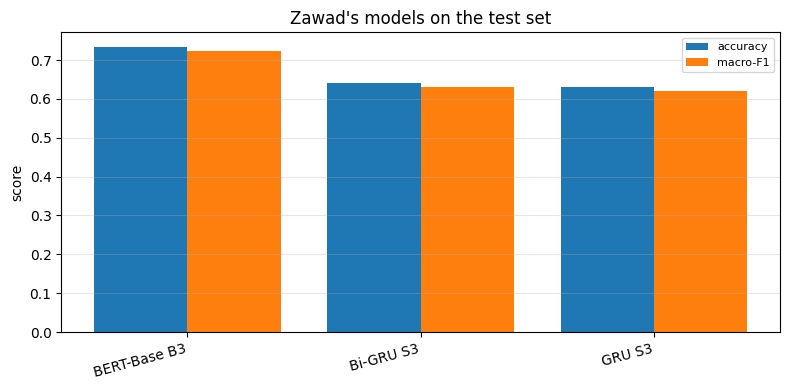

In [ ]:
comparison = ev.compare_models(TEST_RESULTS)
comparison.to_csv(RESULTS_DIR / "test_comparison_zawad.csv", index=False)

print("="*80)
print("TEST COMPARISON — best configuration per model")
print("="*80)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comparison))
ax.bar(x - 0.2, comparison.accuracy, 0.4, label="accuracy")
ax.bar(x + 0.2, comparison.macro_f1, 0.4, label="macro-F1")
ax.set_xticks(x)
ax.set_xticklabels(comparison.model, rotation=15, ha="right")
ax.set_ylabel("score")
ax.set_title("Zawad's models on the test set")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "zawad_test_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("="*80)
print("FILES WRITTEN")
print("="*80)
n = 0
for p in sorted(RESULTS_DIR.rglob("*")) + sorted(FIG_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(DATA_DIR)}  ({p.stat().st_size / 1e3:.0f} KB)")
        n += 1
print(f"\n{n} files under results/zawad/ and figures/zawad/")
print("no writes to splits/, representations/ or utils/")

FILES WRITTEN
  results/zawad/bert/checkpoint_best/config.json  (2 KB)
  results/zawad/bert/checkpoint_best/model.safetensors  (438014 KB)
  results/zawad/bert/checkpoint_best/tokenizer.json  (711 KB)
  results/zawad/bert/checkpoint_best/tokenizer_config.json  (0 KB)
  results/zawad/bert/history/BERT_ABL_512.json  (1 KB)
  results/zawad/bert/history/BERT_B1.json  (1 KB)
  results/zawad/bert/history/BERT_B2.json  (1 KB)
  results/zawad/bert/history/BERT_B3.json  (1 KB)
  results/zawad/bert/reports/test_BERT-Base_ABL-512.json  (9 KB)
  results/zawad/bert/reports/test_BERT-Base_B3.json  (9 KB)
  results/zawad/gru/history/Bi-GRU_S1.json  (2 KB)
  results/zawad/gru/history/Bi-GRU_S2.json  (2 KB)
  results/zawad/gru/history/Bi-GRU_S3.json  (2 KB)
  results/zawad/gru/history/GRU_S1.json  (3 KB)
  results/zawad/gru/history/GRU_S2.json  (3 KB)
  results/zawad/gru/history/GRU_S3.json  (2 KB)
  results/zawad/gru/reports/test_Bi-GRU_S3.json  (9 KB)
  results/zawad/gru/reports/test_GRU_S3.json  (9 

=== CONTRIB END ===